In [ ]:
!pip install kagglehub codecarbon scikit-learn pandas

In [ ]:
import kagglehub
import os
import numpy as np
import struct

# Download dataset
path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path:", path)

# Find files
files = os.listdir(path)
print("Files:", files)

# Function to load MNIST images from idx3-ubyte file
def load_mnist_images(filepath):
    with open(filepath, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num_images, rows * cols)
    return images

# Function to load MNIST labels from idx1-ubyte file
def load_mnist_labels(filepath):
    with open(filepath, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Load training images and labels
train_images_path = os.path.join(path, "train-images.idx3-ubyte")
train_labels_path = os.path.join(path, "train-labels.idx1-ubyte")

X = load_mnist_images(train_images_path) # pixels
y = load_mnist_labels(train_labels_path) # labels

# Normalize pixel values
X = X / 255.0

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Using Colab cache for faster access to the 'mnist-dataset' dataset.
Path: /kaggle/input/mnist-dataset
Files: ['t10k-labels-idx1-ubyte', 'train-images.idx3-ubyte', 't10k-images-idx3-ubyte', 't10k-labels.idx1-ubyte', 't10k-images.idx3-ubyte', 'train-labels.idx1-ubyte', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte']


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_results = {}

# Assuming models are already trained (from the previous `TRz97a7OYbNv` cell)
for name, model in models.items():
    # Make predictions on the test set
    y_pred = model.predict(X_test)
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_results[name] = accuracy

# Convert accuracy results to a DataFrame for merging
accuracy_df = pd.DataFrame(list(accuracy_results.items()), columns=['Model', 'Accuracy'])

# Merge emissions and accuracy DataFrames
performance_df = pd.merge(df, accuracy_df, on='Model')

print(performance_df)

                 Model  CO2 Emissions (kg)  Accuracy
0  Logistic Regression            0.000110  0.904333
1        Random Forest            0.000015  0.943167
2                  SVM            0.000053  0.962333


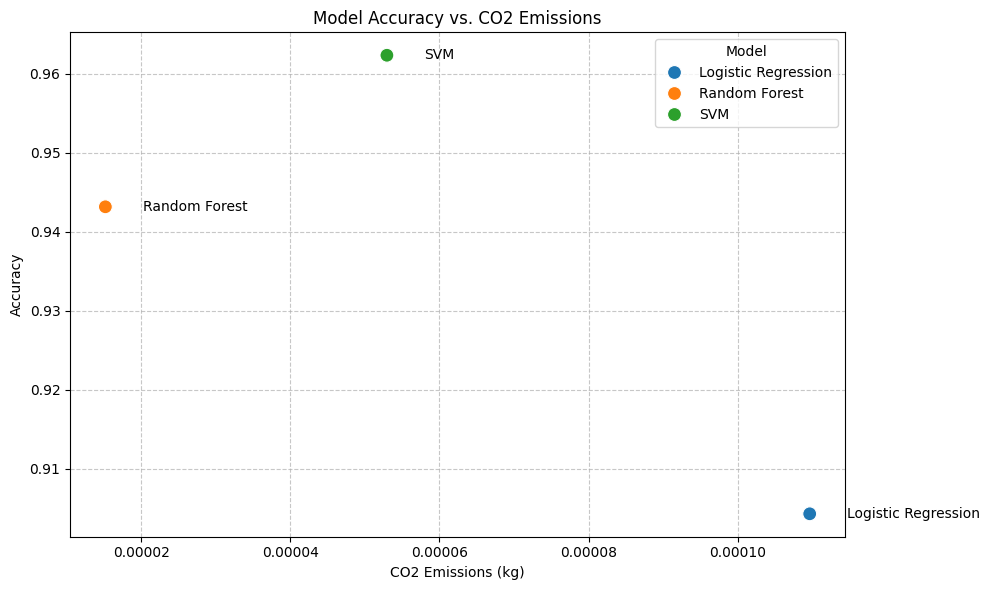

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='CO2 Emissions (kg)', y='Accuracy', hue='Model', data=performance_df, s=100)

for i, row in performance_df.iterrows():
    plt.text(row['CO2 Emissions (kg)'] + 0.000005, row['Accuracy'], row['Model'], ha='left', va='center')

plt.title('Model Accuracy vs. CO2 Emissions')
plt.xlabel('CO2 Emissions (kg)')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

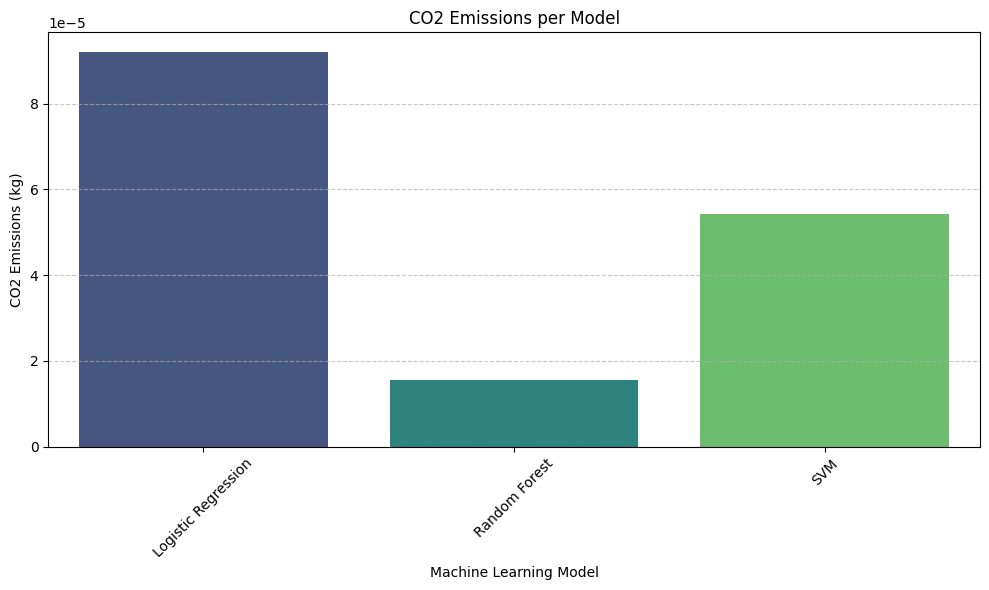

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='CO2 Emissions (kg)', data=df, palette='viridis', hue='Model', legend=False)
plt.title('CO2 Emissions per Model')
plt.xlabel('Machine Learning Model')
plt.ylabel('CO2 Emissions (kg)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from codecarbon import EmissionsTracker

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=50),
    "SVM": SVC()
}

results = {}

# Limit data for speed (important engineering decision)
X_small = X_train[:10000]
y_small = y_train[:10000]

for name, model in models.items():
    print(f"\nRunning {name}...")

    tracker = EmissionsTracker()
    tracker.start()

    model.fit(X_small, y_small)

    emissions = tracker.stop()

    results[name] = emissions
    print(f"{name} Emissions: {emissions:.6f} kg CO2")

[codecarbon WARNING @ 04:31:30] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:31:30] [setup] RAM Tracking...
[codecarbon INFO @ 04:31:30] [setup] CPU Tracking...
[codecarbon WARNING @ 04:31:30] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 04:31:30] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 04:31:30] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.20GHz
[codecarbon WARNING @ 04:31:30] No CPU tracking mode found. Falling back on CPU constant mode.
[codecarbon INFO @ 04:31:30] [setup] GPU Tracking...
[codecarbon INFO @ 04:31:30] No GPU found.
[codecarbon INFO @ 04:31:30] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation mo


Running Logistic Regression...


[codecarbon INFO @ 04:31:45] Energy consumed for RAM : 0.000042 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 04:31:45] Delta energy consumed for CPU with constant : 0.000177 kWh, power : 42.5 W
[codecarbon INFO @ 04:31:45] Energy consumed for All CPU : 0.000177 kWh
[codecarbon INFO @ 04:31:45] 0.000219 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon INFO @ 04:31:57] Energy consumed for RAM : 0.000073 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 04:31:57] Delta energy consumed for CPU with constant : 0.000134 kWh, power : 42.5 W
[codecarbon INFO @ 04:31:57] Energy consumed for All CPU : 0.000311 kWh
[codecarbon INFO @ 04:31:57] 0.000384 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 04:31:57] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:31:57] [setup] RAM Tracking...
[codecarbon INFO @ 04:31:57] [setup] CPU Tracking...
[codecarbon WARNING @ 04:31:57] We saw t

Logistic Regression Emissions: 0.000110 kg CO2

Running Random Forest...


[codecarbon INFO @ 04:32:01] Energy consumed for RAM : 0.000010 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 04:32:01] Delta energy consumed for CPU with constant : 0.000043 kWh, power : 42.5 W
[codecarbon INFO @ 04:32:01] Energy consumed for All CPU : 0.000043 kWh
[codecarbon INFO @ 04:32:01] 0.000053 kWh of electricity and 0.000000 L of water were used since the beginning.
[codecarbon WARNING @ 04:32:01] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 04:32:01] [setup] RAM Tracking...
[codecarbon INFO @ 04:32:01] [setup] CPU Tracking...
[codecarbon WARNING @ 04:32:01] We saw that you have a Intel(R) Xeon(R) CPU @ 2.20GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 04:32:01] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 04:32:01] CPU Model on constan

Random Forest Emissions: 0.000015 kg CO2

Running SVM...


[codecarbon INFO @ 04:32:13] Energy consumed for RAM : 0.000035 kWh. RAM Power : 10.0 W
[codecarbon INFO @ 04:32:13] Delta energy consumed for CPU with constant : 0.000150 kWh, power : 42.5 W
[codecarbon INFO @ 04:32:13] Energy consumed for All CPU : 0.000150 kWh
[codecarbon INFO @ 04:32:13] 0.000185 kWh of electricity and 0.000000 L of water were used since the beginning.


SVM Emissions: 0.000053 kg CO2


In [ ]:
import pandas as pd

df = pd.DataFrame(list(results.items()), columns=["Model", "CO2 Emissions (kg)"])
print(df)

                 Model  CO2 Emissions (kg)
0  Logistic Regression            0.000110
1        Random Forest            0.000015
2                  SVM            0.000053
